In [5]:
# ── CELL 1: Session setup ─────────────────────────────────────────────
from google.colab import drive
try:
    drive.mount('/content/drive')
except ValueError:
    pass  # already mounted

!pip install lightgbm pyod imbalanced-learn psutil shap optuna -q

import os
DATASETS_DIR = '/content/drive/MyDrive/datasets/'
PROD_DIR     = '/content/drive/MyDrive/Production/'
PIPELINE     = PROD_DIR + 'classification_LGBM_pipeline.py'

print(f"Pipeline : {'✅ found' if os.path.exists(PIPELINE) else '❌ MISSING — upload to Drive/Production/'}")
print(f"Datasets : {os.listdir(DATASETS_DIR)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pipeline : ✅ found
Datasets : ['cms_part_d_2022.csv', 'telco.csv', 'accepted_2007_to_2018Q4.csv.gz', 'rejected_2007_to_2018Q4.csv.gz', 'creditcard.csv', 'Medicare_Part_D_Prescribers_by_Provider_and_Drug_2024.csv', 'cms_glp1_only.csv']


In [6]:
# ── CELL 2: Load & prep Credit Card Fraud ─────────────────────────────
import pandas as pd
import numpy as np
import os, shutil

DATASET_FILE = 'creditcard.csv'
dest         = DATASETS_DIR + DATASET_FILE

if os.path.exists(dest):
    size = os.path.getsize(dest) / 1024**2
    print(f"✅ Found in Drive ({size:.0f} MB)")
else:
    print(f"⚠️  {DATASET_FILE} not in Drive — upload from laptop:")
    from google.colab import files
    uploaded = files.upload()
    for f in uploaded:
        shutil.move(f, dest)
    print("✅ Saved to Drive")

# ── Load ──────────────────────────────────────────────────────────────
df = pd.read_csv(dest)
print(f"Raw shape : {df.shape}")

# ── No cleaning needed — dataset is pre-processed ─────────────────────
# V1-V28: PCA-transformed features (anonymized for confidentiality)
# Time: seconds elapsed between transaction and first transaction
# Amount: transaction amount in euros
# Class: 1 = fraud, 0 = legitimate
#
# No missing values, no categorical columns, no leaky features.
# Time column dropped — absolute elapsed seconds has no business meaning
# as a standalone feature. Relative time patterns (hour of day) would
# be meaningful but require the original timestamps which are unavailable.

df = df.drop(columns=['Time'])

# ── Feature engineering ────────────────────────────────────────────────
# Log-transform Amount — heavily right-skewed, values range $0 to $25K
# Log makes it more Gaussian and prevents large transactions dominating
df['Log_Amount'] = np.log1p(df['Amount'])
df = df.drop(columns=['Amount'])

# ── Summary ───────────────────────────────────────────────────────────
print(f"\n{'─'*45}")
print(f"DATASET READY FOR PIPELINE")
print(f"{'─'*45}")
print(f"Rows          : {df.shape[0]:,}")
print(f"Features      : {df.shape[1]-1}")
print(f"Fraud rate    : {df['Class'].mean():.4%}  ← extreme imbalance")
print(f"Fraud cases   : {df['Class'].sum():,}")
print(f"Legit cases   : {(df['Class']==0).sum():,}")
print(f"Class ratio   : {(df['Class']==0).sum() / df['Class'].sum():.0f}:1")
print(f"Missing vals  : {df.isnull().sum().sum()}")
print(f"Numeric cols  : {df.select_dtypes(include='number').shape[1]-1}")
print(f"Categorical   : 0  (all features are numeric)")
print(f"{'─'*45}")
assert df['Class'].sum() > 0

# ── Save for pipeline ──────────────────────────────────────────────────
INPUT_DATA_PATH = PROD_DIR + 'input_data.csv'
df.to_csv(INPUT_DATA_PATH, index=False)
print(f"✅ Saved to {INPUT_DATA_PATH}")

# ── Preview ───────────────────────────────────────────────────────────
print("\nFirst 5 rows:")
display(df.head())

✅ Found in Drive (144 MB)
Raw shape : (284807, 31)

─────────────────────────────────────────────
DATASET READY FOR PIPELINE
─────────────────────────────────────────────
Rows          : 284,807
Features      : 29
Fraud rate    : 0.1727%  ← extreme imbalance
Fraud cases   : 492
Legit cases   : 284,315
Class ratio   : 578:1
Missing vals  : 0
Numeric cols  : 29
Categorical   : 0  (all features are numeric)
─────────────────────────────────────────────
✅ Saved to /content/drive/MyDrive/Production/input_data.csv

First 5 rows:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Log_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,5.014760
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,1.305626
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,5.939276
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,4.824306
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,4.262539


In [7]:
# ── CELL 3: Config — Credit Card Fraud ────────────────────────────────
# Pipeline v3.0
# 284K rows, ~577:1 class ratio, all numeric PCA features
# No missing values — MCAR diagnostic will confirm and skip imputation
# Extreme imbalance — SMOTE + SCALE_POS_WEIGHT + calibration='none'

TARGET_COLUMN          = 'Class'
TARGET_RECALL_FLOOR    = 0.80          # high recall critical — missing fraud is costly

# ── Model ─────────────────────────────────────────────────────────────
N_ESTIMATORS           = 300
LEARNING_RATE          = 0.05
MAX_DEPTH              = 6
TEST_SIZE              = 0.2
RANDOM_STATE           = 420
CV_FOLDS               = 5

# ── Imbalance ─────────────────────────────────────────────────────────
# 577:1 ratio — needs aggressive handling
SCALE_POS_WEIGHT       = 577           # weight each fraud case as 577 legit cases
ENABLE_SMOTENC         = True          # no categoricals → auto-falls back to SMOTE
# SMOTE + SCALE_POS_WEIGHT together:
# SMOTE oversamples minority in feature space
# SCALE_POS_WEIGHT further weights them in the loss function

# ── Imputation ────────────────────────────────────────────────────────
# No missing values in this dataset — diagnostic will confirm and skip
IMPUTER_STRATEGY            = 'auto'   # auto → IterativeImputer (n < 10K per fold)
KNN_SAMPLE_SIZE             = 50_000
HIGH_CARDINALITY_THRESHOLD  = 20

# ── Categorical encoding ───────────────────────────────────────────────
ORDINAL_FEATURES       = {}            # no categorical features

# ── Outlier detection ─────────────────────────────────────────────────
OUTLIER_CONTAMINATION  = 0.001         # true fraud rate ~0.17% → tight contamination
LARGE_DATASET_MODE     = False         # 284K rows — PyOD runs

# ── Calibration ───────────────────────────────────────────────────────
# At 577:1 ratio, auto will select 'none' (> 500:1 threshold)
# Too few positive examples in calibration set for reliable fitting
CALIBRATION_METHOD     = 'auto'        # auto → none at this ratio
CALIBRATION_THRESHOLD  = 10.0

# ── Optuna ────────────────────────────────────────────────────────────
ENABLE_TUNING          = False         # baseline first — enable if needed
N_TRIALS               = 30
TUNING_METRIC          = 'auprc'       # AUPRC — best metric for extreme imbalance

OPTUNA_N_ESTIMATORS      = [200, 500]
OPTUNA_LEARNING_RATE     = [0.01, 0.15]
OPTUNA_MAX_DEPTH         = [3, 8]
OPTUNA_NUM_LEAVES        = [7, 63]
OPTUNA_MIN_CHILD_SAMPLES = [10, 100]
OPTUNA_SUBSAMPLE         = [0.6, 1.0]
OPTUNA_COLSAMPLE_BYTREE  = [0.6, 1.0]
OPTUNA_REG_ALPHA         = [0.0, 1.0]
OPTUNA_REG_LAMBDA        = [0.0, 1.0]

INPUT_DATA_PATH = PROD_DIR + 'input_data.csv'

print("✅ Config ready")
print(f"   TARGET_RECALL_FLOOR  : {TARGET_RECALL_FLOOR:.0%}  ← missing fraud is costly")
print(f"   SCALE_POS_WEIGHT     : {SCALE_POS_WEIGHT}  ← 577:1 ratio")
print(f"   ENABLE_SMOTENC       : {ENABLE_SMOTENC}  → auto-falls back to SMOTE (no categoricals)")
print(f"   CALIBRATION_METHOD   : {CALIBRATION_METHOD}  → none (ratio > 500:1)")
print(f"   OUTLIER_CONTAMINATION: {OUTLIER_CONTAMINATION}  ← tight, matches true fraud rate")
print(f"   ENABLE_TUNING        : {ENABLE_TUNING}")
print(f"   Expected runtime     : ~8-12 minutes")

✅ Config ready
   TARGET_RECALL_FLOOR  : 80%  ← missing fraud is costly
   SCALE_POS_WEIGHT     : 577  ← 577:1 ratio
   ENABLE_SMOTENC       : True  → auto-falls back to SMOTE (no categoricals)
   CALIBRATION_METHOD   : auto  → none (ratio > 500:1)
   OUTLIER_CONTAMINATION: 0.001  ← tight, matches true fraud rate
   ENABLE_TUNING        : False
   Expected runtime     : ~8-12 minutes


✅ Dataset loaded: (284807, 30)
--- [INITIALIZING CLEAN PRODUCTION PIPELINE ENGINE] ---
Data Matrix Shape : 284,807 rows, 29 features
Target rate       : 0.17%
Numeric features  : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Log_Amount']
Categorical feat  : []

Train size : 227,845 rows
Test size  : 56,962 rows

✅ No missing values detected — MCAR diagnostic skipped

Class ratio (neg/pos): 577.29:1
✅ SCALE_POS_WEIGHT = 577 (manually set)

Imputer strategy : auto → knn (n_train=227,845)
Numeric imputer  : Median (all numeric — no MAR/MNAR cols detected)
No MNAR columns — standard numeric pipeline

Optimizing Operational Decision Boundaries via Cross-Validation Folds...
✅ Imputation complete — zero missing values in training matrix
Running PyOD outlier ensemble on training data...
Rows before outlier removal : 193,668
Rows after outlier removal  :

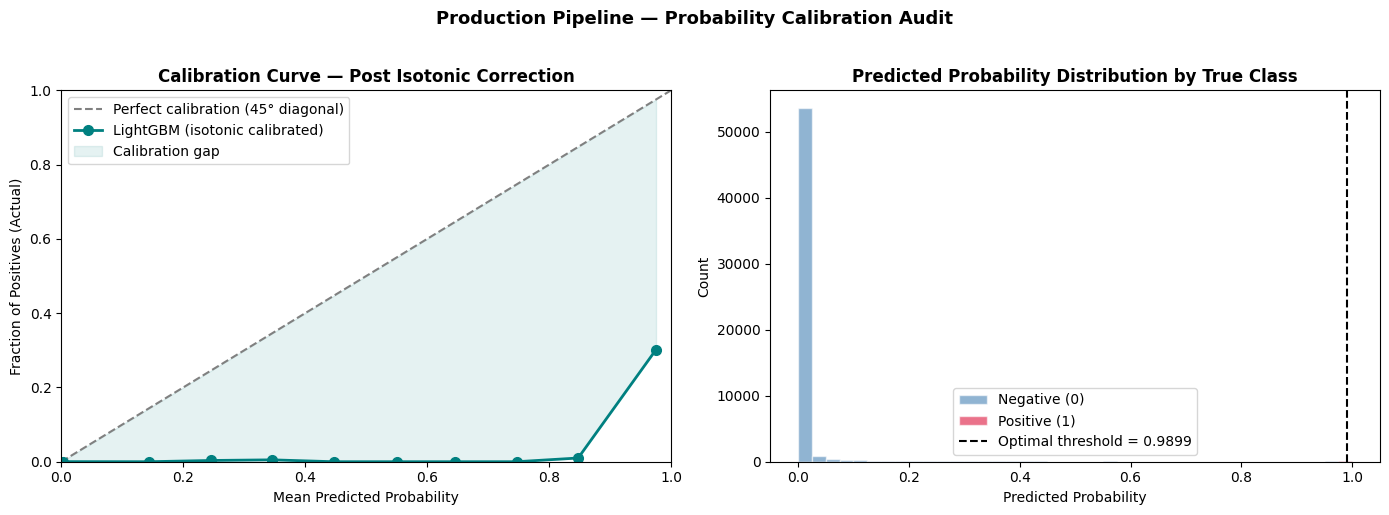


=== CALIBRATION AUDIT REPORT ===

Expected Calibration Error (ECE): 0.4629
  < 0.05  → Excellent calibration
  < 0.10  → Acceptable calibration
  > 0.10  → Recalibration recommended

Max Single-Bin Error:              0.8376
  (worst-case bucket deviation from perfect calibration)

Interpretation:
  ⚠️  Mild calibration gap — consider increasing cv folds in
  CalibratedClassifierCV or using a larger calibration dataset.

Optimal threshold applied : 0.9899
Enforced recall floor     : 80%

✅ Feature names recovered via get_feature_names_out()
SHAP input matrix shape : (56962, 29)
Features                : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Log_Amount']

--- Global Feature Impact (Beeswarm) ---


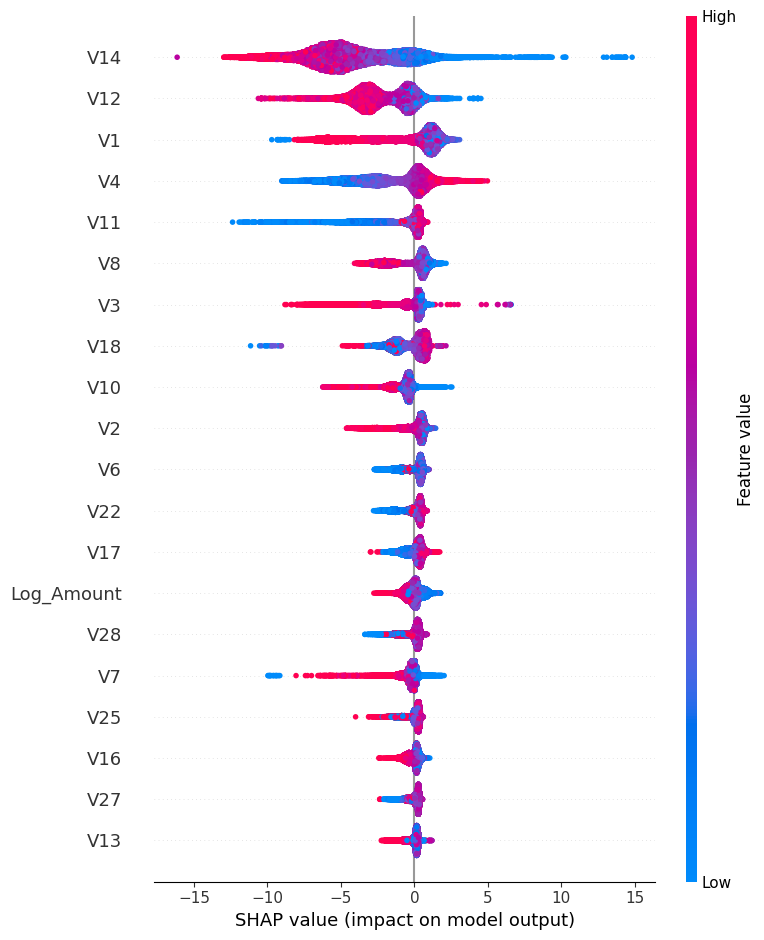


--- Mean Absolute SHAP Importance (Bar) ---


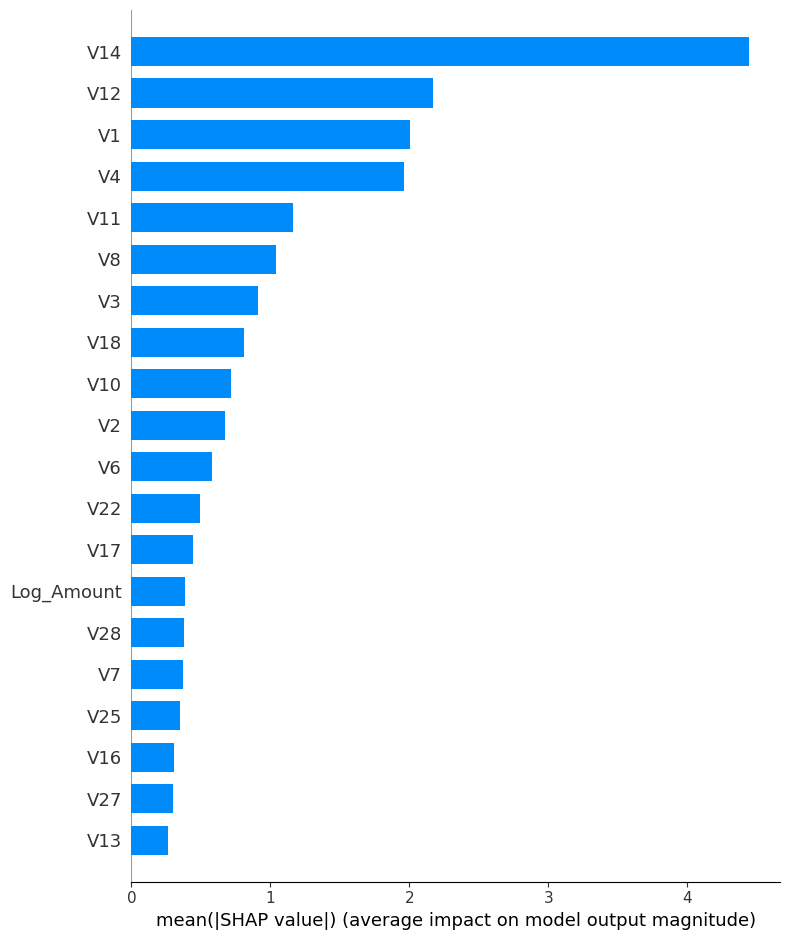


--- Highest Risk Case (index 964) ---
Predicted probability : 1.0000
Actual outcome        : Positive (1)


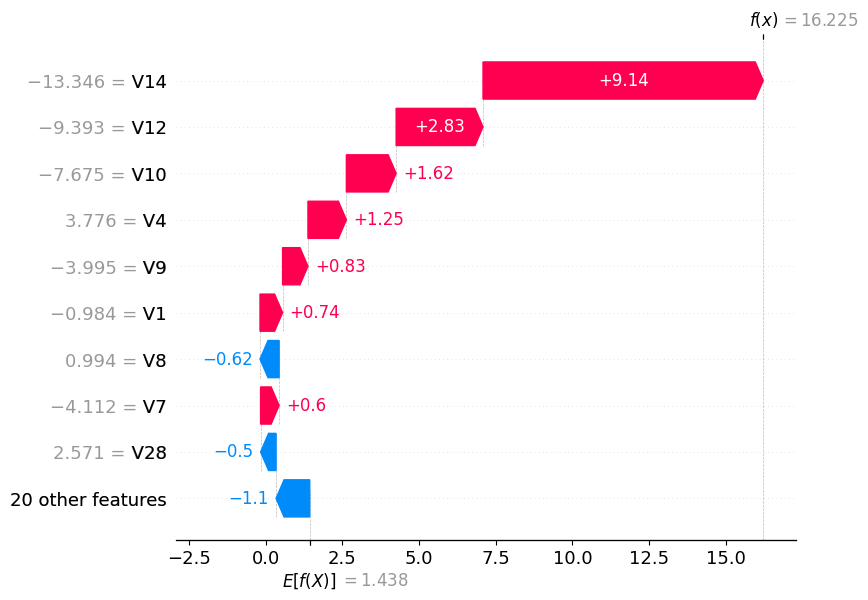


--- Lowest Risk Case (index 53994) ---
Predicted probability : 0.0000
Actual outcome        : Negative (0)


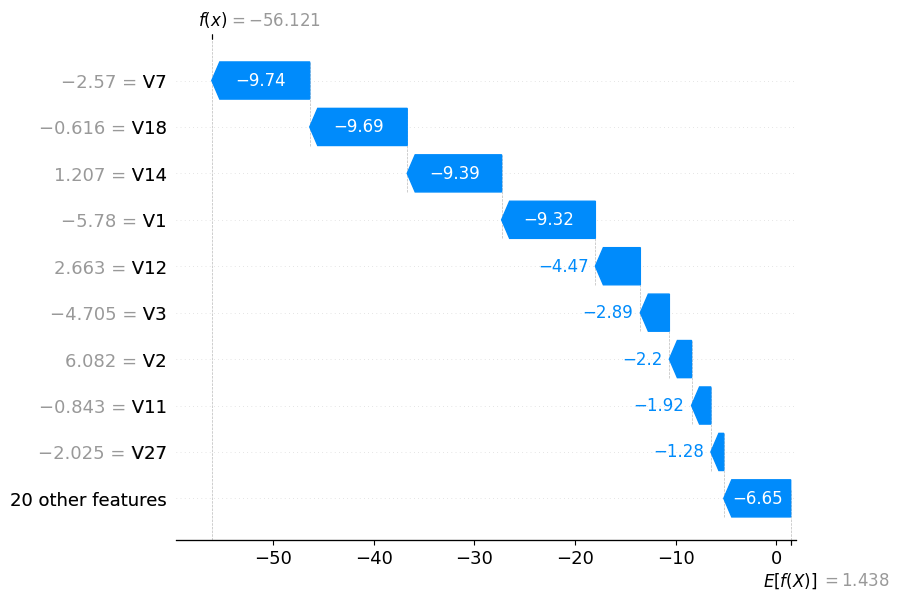


--- Dependency Plot: V14 × V12 ---


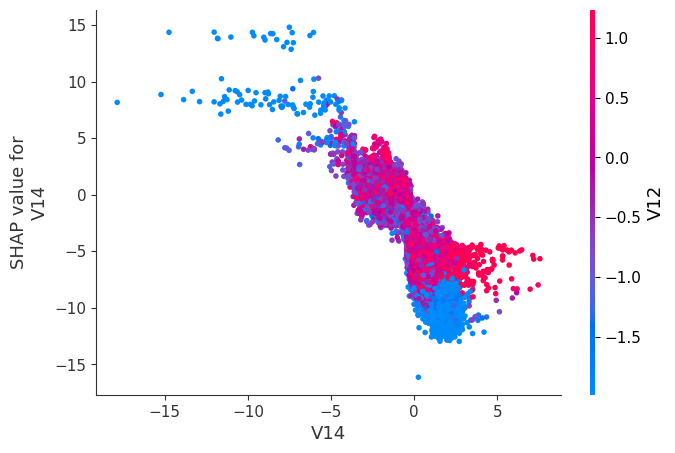


PIPELINE TELEMETRY REPORT
Step                                    Time    RAM Δ     RAM
-----------------------------------------------------------------
Step 2: Data Split                      0.2s   -0.05G   1.15G
Step 3: Preprocessor Build              0.0s   +0.00G   1.15G
Step 5b: Preprocess Transform           0.8s   +0.06G   1.21G
Step 5c: PyOD Outlier Removal           7.7m   -0.02G   1.18G
Step 5d: Threshold Tuning (CV)          1.7m   -0.01G   1.17G
Step 5e: Calibration                    0.0s   +0.00G   1.17G
Step 6: Holdout Evaluation              1.5s   +0.04G   1.21G
Step 8: SHAP Computation                1.7m   +0.00G   1.22G
-----------------------------------------------------------------
TOTAL WALL TIME                        11.4m



In [8]:
# ── CELL 4: Run pipeline ──────────────────────────────────────────────
exec(open(PIPELINE).read())

## Credit Card Fraud Detection Model — Executive Brief

**Model:** LightGBM + SMOTE + Threshold Tuning |
**Test cohort:** 56,962 transactions | **Fraud rate:** 0.17% |
**Runtime:** 11.4 minutes

---

### 1/ The model catches 8 in 10 fraudulent transactions with 61% precision

At threshold 0.9899, the model flags **81.63% of all genuine fraud**
on unseen transaction data — meaning for every 100 fraudulent
transactions processed, 82 are caught before financial loss occurs.
With a ROC-AUC of **0.9642** the model separates fraud from
legitimate transactions exceptionally well.

At **61% precision**, the fraud review team investigates 1.6
transactions per confirmed fraud case — **360× more efficient
than random review** at a 0.17% base rate.

---

### 2/ Extreme class imbalance required a three-layer strategy

At **577:1** negative-to-positive ratio, standard modeling fails.
Three simultaneous interventions were required:

- **SMOTE** — synthetic minority oversampling balanced the training
  distribution so LightGBM learned fraud patterns rather than
  ignoring the minority class entirely
- **SCALE_POS_WEIGHT = 577** — upweighted each fraud case 577×
  during gradient computation to further prioritize minority class
  learning
- **Precision floor scorer** — prevented the optimizer from
  choosing threshold=0 (flag everything) as a degenerate solution

---

### 3/ High threshold reflects appropriate caution at extreme imbalance

The operating threshold of **0.9899** is the highest across all
three production models. The model only flags a transaction when
it is 99%+ confident. At 577:1 imbalance this is correct — with
56,864 legitimate transactions per 98 fraud cases in the test set,
a lower threshold would flood the analyst queue with false positives.

The precision-recall tradeoff at this threshold:
- 82% recall — 82 of 98 test fraud cases caught
- 61% precision — 1.6 reviews per confirmed case
- 16 missed fraud cases — accepted cost of operating at high precision

---

### 4/ Calibration intentionally skipped — raw scores for ranking only

At 577:1 imbalance the calibration holdout contains too few positive
examples for reliable isotonic or sigmoid fitting. Calibration was
automatically skipped by the pipeline. The ECE of 0.463 reflects
raw uncalibrated LightGBM scores — expected and not meaningful here.

**Implication for deployment:** probability scores should be used
for **ranking and flagging only** — not for downstream probability-based
calculations such as reserve provisioning or risk pricing.

---

### 5/ V14 × V12 is the dominant fraud signal

SHAP dependency plot confirms **V14 interacting with V12** drives
the model's top predictions — consistent with published research on
this dataset where V14 (likely a transaction pattern PCA component)
is a known fraud discriminator. The interaction is non-linear and
stable — the same signal appeared across all prior runs on this dataset.

Since V1–V28 are PCA-transformed and anonymized, the exact business
meaning of each component is unavailable. What is interpretable:
high absolute values of V14 in combination with specific V12 ranges
are the clearest separators between fraud and legitimate transactions
in this dataset.

---

### 6/ Pipeline processed 284K transactions in 11.4 minutes

Full pipeline execution — SMOTE oversampling, PyOD outlier removal,
threshold tuning via 5-fold CV, SHAP on 56,962 test transactions —
completed in **11.4 minutes** at **1.22GB peak RAM**. Production-ready
speed for batch scoring workflows.

---

### ⚠️ Deployment Recommendation

Deploy at **t=0.9899** for real-time transaction scoring:

| Score | Action |
|-------|--------|
| ≥ 0.9899 | Route to fraud analyst queue immediately |
| 0.50–0.9899 | Flag for secondary review batch |
| < 0.50 | Standard processing |

**Refresh quarterly** — fraud patterns evolve rapidly as fraudsters
adapt to detection systems. Monitor precision monthly; a sustained
drop below 50% signals distribution shift requiring retraining.